In [ ]:
#!git clone https://github.com/MateusMaruzka/aqm-dataset.git
#cd aqm-dataset
#mv /content/aqm-dataset/* /content/

In [ ]:
#cd ~/projects/fiware-project/ml/app
#mv aqm-dataset/* .

In [1]:
#!/usr/bin/env python
# coding: utf-8

# Standard library imports
import sys
import warnings
from typing import Dict, List, Optional, Tuple, Union
from itertools import product

# Third-party imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Scientific computing
from scipy import stats
from scipy.stats import uniform, randint


# Machine Learning
from sklearn import __version__ as sklearn_version
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
# from sklearn.neural_network import MLPRegressor
# from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    RandomizedSearchCV,
    RepeatedKFold,
    cross_val_score,
    cross_validate
)
import pickle
from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error,
    mean_absolute_percentage_error
)

plt.rcParams.update({
    "text.usetex": False,
    "font.family": "serif",
    "font.sans-serif": "Times",
    "font.size" : 10,
})

# Custom libs
try:
    from envcity_plot_lib import *
    ENVCITY_AVAILABLE = True
except ImportError:
    warnings.warn("envcity_plot_lib not available")
    ENVCITY_AVAILABLE = False

try:
    from alphasense_b_sensors.alphasense_sensors import *
    ALPHASENSE_AVAILABLE = True
except ImportError:
    warnings.warn("alphasense_b_sensors not available")
    ALPHASENSE_AVAILABLE = False

# Configuration
plt.rcParams.update({
    "text.usetex": False,
    "font.family": "serif",
    "font.sans-serif": "Times",
    "font.size": 10,
    "figure.figsize": (10, 6),
    "axes.grid": True,
    "grid.alpha": 0.3
})
from alphasense_b_sensors import *

/home/pedro-mujica/projects/fiware-project/ml/app/envcity_plot_lib.py:49: SyntaxWarning: invalid escape sequence '\m'
  ax1.set_title(f"$\mathrm{{{latex_labels[idx]}}}$ Concentration from {start} to {end}")
/home/pedro-mujica/projects/fiware-project/ml/app/envcity_plot_lib.py:94: SyntaxWarning: invalid escape sequence '\m'
  ax.set_title(f"$\mathrm{{{latex_labels[idx]}}}$ Concentration from {start} to {end}")
/home/pedro-mujica/projects/fiware-project/ml/app/envcity_plot_lib.py:136: SyntaxWarning: invalid escape sequence '\m'
  ax.set_title(f"$\mathrm{{{latex_labels[idx]}}}$ Concentration from {start} to {end}", fontsize = 10)
/home/pedro-mujica/projects/fiware-project/ml/app/envcity_plot_lib.py:162: SyntaxWarning: invalid escape sequence '\m'
  ax.set_title(f"$\mathrm{{{latex_labels[idx]}}}$ Concentration from {start} to {end}", fontsize = 10)
/home/pedro-mujica/projects/fiware-project/ml/app/envcity_plot_lib.py:218: SyntaxWarning: invalid escape sequence '\m'
  plt.suptitle(f"Compari

In [2]:
!pip install scikit-learn==1.7.1  # Substitua pela versão desejada
import sklearn
print(sklearn.__version__)  # Confirme a versão

1.7.1


In [3]:

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore', category=FutureWarning)

def print_versions() -> None:
    """Print versions of key libraries."""
    print("="*50)
    print("LIBRARY VERSIONS")
    print("="*50)
    print(f"Python: {sys.version.split()[0]}")
    print(f"NumPy: {np.__version__}")
    print(f"Pandas: {pd.__version__}")
    print(f"Matplotlib: {plt.matplotlib.__version__}")
    print(f"Seaborn: {sns.__version__}")
    print(f"Scikit-learn: {sklearn_version}")
    print("="*50)

print_versions()

def exploratory_analysis(dict_data_e1, dict_data_e2, labels, latex_labels, start, end):

    table_exploratory_analysis = {}

    for idx, l in enumerate(labels):

        e1 = dict_data_e1[l]
        e2 = dict_data_e2[l]

        concatenated = pd.concat([e1, e2], axis=1, keys=['Station 1', 'Station 2'])
        table_exploratory_analysis[l] = describe(concatenated, ['median'], ['25%', '50%', '75%'])

    return table_exploratory_analysis

class dataLoader:
    def __init__(self):
        pass

LIBRARY VERSIONS
Python: 3.12.3
NumPy: 2.3.2
Pandas: 2.3.1
Matplotlib: 3.10.8
Seaborn: 0.13.2
Scikit-learn: 1.7.1


In [6]:

#lendo dados e mais
aqm = pd.read_csv('envcity_df_sp_dataset_2023.csv')

aqm.set_index('time', inplace=True)
aqm.index = pd.to_datetime(aqm.index)

labels =  ['co_we', 'co_ae', "temp"]
preffix = ['e2sp_']
label_ref= 'iag_co'

df = aqm

df = aqm[[preffix[0] + labels[0], preffix[0] + labels[1], 'pin_umid', label_ref, preffix[0] + "temp"]]

df.index = pd.to_datetime(df.index)
df = df.resample('5min').mean()
df = df.interpolate(method = 'linear', limit=1, limit_area = "inside")
df = df.dropna()

print(df.shape)

(9597, 5)


In [7]:


#ALPHASENSE E BLA BLA
co = Alphasense_Sensors("CO-B4", "162741354")
no2 = Alphasense_Sensors("NO2-B43F", "202742056")
so2 = Alphasense_Sensors("SO2-B4", "164240348")
ox = Alphasense_Sensors("OX-B431", "204240461")

# to mV
we = df[preffix[0] + labels[0]]*1000
ae = df[preffix[0] + labels[1]]*1000
# temp = df[preffix[0] + 'temp']


ppb = ((we - co.electronic_we) - (ae - co.electronic_ae))/co.sensitivity

df[preffix[0] + 'co'] = ppb / 1000


#%%

print(df.describe())
#%%
     

        e2sp_co_we   e2sp_co_ae     pin_umid       iag_co     e2sp_temp  \
count  9597.000000  9597.000000  9597.000000  9597.000000  9.597000e+03   
mean      0.479835     0.279989    75.604981     1.797280  1.002118e+01   
std       0.159594     0.060115    17.022597     0.345834  1.109849e+01   
min       0.217398     0.157875    26.000000     1.142200  0.000000e+00   
25%       0.379200     0.271204    67.000000     1.551600  5.693801e-39   
50%       0.427750     0.279750    82.000000     1.712000  9.100000e+00   
75%       0.525141     0.290927    88.000000     1.921600  1.720000e+01   
max       3.000000     4.000000    96.000000     3.205600  3.890000e+01   

           e2sp_co  
count  9597.000000  
mean      0.453055  
std       0.385694  
min      -2.487745  
25%       0.203585  
50%       0.329044  
75%       0.568771  
max       4.327692  


In [8]:

Yco = df[label_ref]
Xco = df.loc[Yco.index][[preffix[0] + 'co', preffix[0] + 'co_we',preffix[0] + 'co_ae', preffix[0] + 'temp', 'pin_umid']]

In [9]:
#Realizando treino e teste
X_train, X_valid, y_train, y_valid = train_test_split(Xco, Yco, train_size=0.6)
X_train, X_test, y_train, y_test = train_test_split(X_train, y_train)


In [10]:
#verificando tamanhos
kfold = RepeatedKFold(n_splits = 5, n_repeats = 1)
# kfold = StratifiedKFold(n_splits = 5)

print(X_train.shape)
print(X_test.shape)
print(X_valid.shape)

(4318, 5)
(1440, 5)
(3839, 5)


In [11]:
#GERA PIPELINE
param_grid = {"randomforestregressor__n_estimators": np.array([32, 64, 124]),
              "randomforestregressor__max_depth": [None, 32],
              "randomforestregressor__bootstrap" : [False, True],
              'randomforestregressor__max_features': ["sqrt", None],
              'randomforestregressor__criterion': ['squared_error' ]}# 'absolute_error', 'friedman_mse']}

regressor = make_pipeline(RandomForestRegressor())




In [12]:
#faz o gridSearch
gs = GridSearchCV(regressor, param_grid=param_grid, n_jobs=-1, verbose = 3,\
                  return_train_score=True, cv = kfold, error_score = 'raise')


res = gs.fit(X_train,y_train)

Fitting 5 folds for each of 24 candidates, totalling 120 fits
[CV 1/5] END randomforestregressor__bootstrap=False, randomforestregressor__criterion=squared_error, randomforestregressor__max_depth=None, randomforestregressor__max_features=sqrt, randomforestregressor__n_estimators=32;, score=(train=1.000, test=0.917) total time=   0.7s
[CV 5/5] END randomforestregressor__bootstrap=False, randomforestregressor__criterion=squared_error, randomforestregressor__max_depth=None, randomforestregressor__max_features=sqrt, randomforestregressor__n_estimators=32;, score=(train=1.000, test=0.913) total time=   0.7s
[CV 4/5] END randomforestregressor__bootstrap=False, randomforestregressor__criterion=squared_error, randomforestregressor__max_depth=None, randomforestregressor__max_features=sqrt, randomforestregressor__n_estimators=32;, score=(train=1.000, test=0.914) total time=   0.7s
[CV 2/5] END randomforestregressor__bootstrap=False, randomforestregressor__criterion=squared_error, randomforestreg

In [24]:
from joblib import dump

# Salve o modelo no formato .joblib

#exporta o modelo após GridSearch
with open('RF_Regressor.joblib', 'wb') as f:
    dump(gs.best_estimator_, 'RF_Regressor.joblib')



In [14]:
# %% Resultado da otimização
print(train_data := pd.DataFrame(res.cv_results_))

with open('tabela_treino.tex', 'w') as f:
    f.write(train_data.style.to_latex())


    mean_fit_time  std_fit_time  mean_score_time  std_score_time  \
0        0.725196      0.097448         0.025952        0.008463   
1        1.360720      0.017865         0.037852        0.004616   
2        2.652646      0.120663         0.068360        0.012763   
3        1.377144      0.040898         0.018588        0.002179   
4        2.755835      0.101581         0.032539        0.000700   
5        4.903900      0.189186         0.050234        0.002479   
6        0.651069      0.025349         0.018534        0.001928   
7        1.360220      0.117506         0.039810        0.012302   
8        2.165846      0.074679         0.052426        0.003966   
9        1.199387      0.093694         0.017617        0.005773   
10       2.168108      0.071772         0.033340        0.004520   
11       4.130076      0.123771         0.057015        0.007247   
12       0.352746      0.026277         0.013042        0.000992   
13       0.696128      0.024253         0.025625

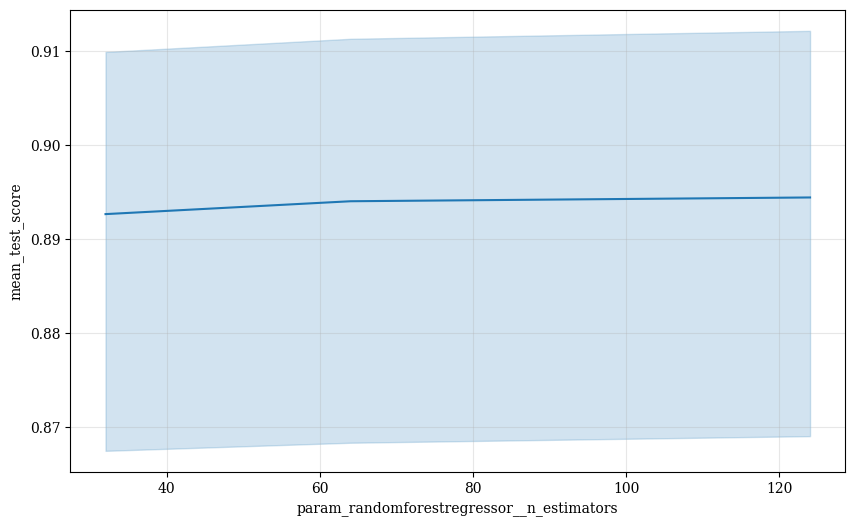

In [15]:
var = 'squared_error'
var2 = 'sqrt'
# mse = train_data.query("param_randomforestregressor__criterion == @var and param_randomforestregressor__max_features == @var2")
mse_df = train_data.query("param_randomforestregressor__criterion == @var")

with open('tabela_treino_mse.tex', 'w') as f:
    f.write(mse_df.style.to_latex())

mse_df = mse_df.sort_values('param_randomforestregressor__n_estimators', axis = 0)

# Plot the responses for different events and regions
plt.figure()
sns.lineplot(x="param_randomforestregressor__n_estimators", y="mean_test_score",
             #hue="param_randomforestregressor__max_features", # style="event",
             data=train_data)
plt.show()

#%%

# print("Linear Regression Model")
# print("Train Score: ", linReg.score(X_train, y_train))
# print("Test Score: ", linReg.score(X_test, y_test))
# print("Validation Score: ", r2_score(y_valid, linReg.predict(X_valid)))
# print("RMSE Score: ", 100*rmse(y_train, linReg.predict(X_train)))

# print(linReg.coef_)

# sns.regplot(x = y_valid, y = linReg.predict(X_valid))
# sns.regplot(x = y_test, y = linReg.predict(X_test))
# plt.gca().axline((0,0), slope=1)
# plt.show()


#%%


Random Forest Model
Train Score:  0.9892171280088743
Test Score:  0.9337000304487875
Validation Score:  0.9239421297307313


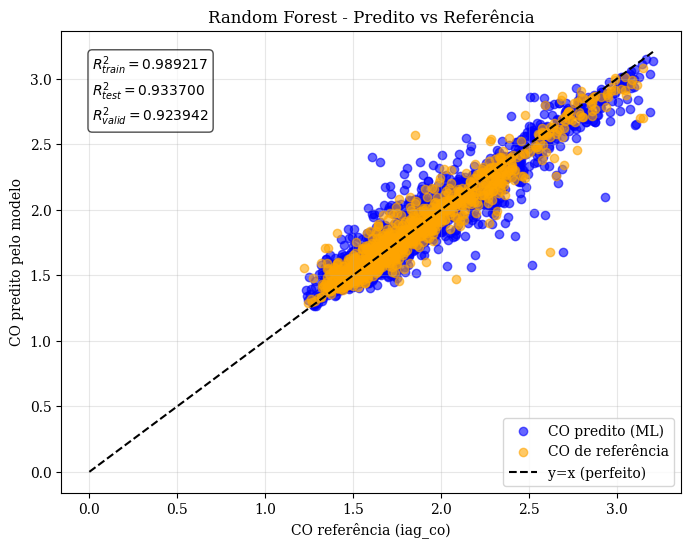

In [16]:

print("Random Forest Model")
print("Train Score: ", gs.score(X_train, y_train))
print("Test Score: ", gs.score(X_test, y_test))
print("Validation Score: ", r2_score(y_valid, gs.predict(X_valid)))
#print("RMSE Score: ", 100*rmse(y_train, gs.predict(X_train)))

plt.figure(figsize=(8,6))

# Predição vs. referência
plt.scatter(y_valid, gs.predict(X_valid), alpha=0.6, label="CO predito (ML)", color="blue")
plt.scatter(y_test, gs.predict(X_test), alpha=0.6, label="CO de referência", color="orange")

# Linha y = x
plt.plot([0, max(y_test.max(), y_valid.max())],
         [0, max(y_test.max(), y_valid.max())],
         color="black", linestyle="--", label="y=x (perfeito)")

# Labels
plt.xlabel("CO referência (iag_co)")
plt.ylabel("CO predito pelo modelo")
plt.title("Random Forest - Predito vs Referência")

# Legenda
plt.legend()

# Adicionando os R² no gráfico
textstr = '\n'.join((
    r'$R^2_{train}=%.6f$' % (gs.score(X_train, y_train), ),
    r'$R^2_{test}=%.6f$' % (gs.score(X_test, y_test), ),
    r'$R^2_{valid}=%.6f$' % (r2_score(y_valid, gs.predict(X_valid)), )))

plt.text(0.05, 0.95, textstr, transform=plt.gca().transAxes,
         fontsize=10, verticalalignment='top',
         bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.7))

plt.show()

# #%% Antes de tudo

# e1_rf = {'co' : pd.DataFrame(data=gs.predict(Xco), index=Xco.index)}
# # e1 = {'co' : df['e2sp_co']}
# e2_ref = {'co' : df['iag_co']}

# plot_data_by_time_and_regr_plot(e1, e2, labels = ['co'], latex_labels = 'co')

# #%%
# ## ['2023-03-18 10:00:00':'2023-03-22 10:00:00'].

# e1_rf = {'co' : pd.DataFrame(data=linReg.predict(Xco), index=Xco.index)}
# # e1 = {'co' : df['e2sp_co']}
# e2_ref = {'co' : df['iag_co']}

# plot_data_by_time_and_regr_plot(e1_rf, e2_ref, labels = ['co'], latex_labels = 'co')

In [ ]:
from joblib import dump


# 1. Salva o melhor modelo do GridSearch no formato .joblib
dump(gs.best_estimator_, 'RF_Regressor.joblib')

# 2. Faz o download do arquivo .joblib para sua máquina
files.download('RF_Regressor.joblib')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>